## 99. Black-Litterman Baseline

## 논문 구현 (Pyo & Lee, 2018)
변동성 예측 없이 **현재 vol_21d로 직접 분류**한 baseline BL 포트폴리오.

## 전체 흐름
```
[Step 1] 자산 분류 (Baseline: 현재 vol_21d 직접 사용)
   ├── vol_21d 오름차순 정렬
   ├── 하위 30% → 저위험 (long)
   └── 상위 30% → 고위험 (short)

[Step 2] 뷰 포트폴리오 구성
   ├── P: 시총 가중 (저위험 +, 고위험 -)
   ├── Q: 고정 Q_FIXED (민감도 분석으로 최적값 자동 탐색)
   └── Ω: He-Litterman 공식 (τ·P·Σ·P^T)

[Step 3] BL 사후 (Sherman-Woodbury)
   └── μ_BL = Π + τΣP^T[P(τΣ)P^T + Ω]^{-1}(q - PΠ)

[Step 4] 포트폴리오 최적화
   └── min (λ/2)w^T Σ w - w^T μ_BL
       s.t. Σw=1, w≥0
```

## 비교 대상
- **BL (Baseline)**: 현재 vol_21d 분류 → BL 최적화
- **CAPM 균형**: BL 없이 μ=Π 그대로 최적화
- **S&P 500 (SPY)**: 시장 지수

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from bl_utils import *  # 공통 BL/Q/성과 유틸리티

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '99_baseline'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW = 60    # 공분산 추정 윈도우 (개월)
TAU          = 0.1
PCT_GROUP    = 0.30
START_PRED   = '2010-01-01'  # 60개월 워밍업 → 2010-01부터 예측
END_PRED     = '2024-12-31'  # 관측 기간 상한

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[(all_dates >= START_PRED) & (all_dates <= END_PRED)]

print(f'패널: {panel.shape}')
print(f'컬럼: {list(panel.columns)}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')

패널: (108135, 11)
컬럼: ['vol_21d', 'vol_60d', 'vol_252d', 'beta_252d', 'close', 'log_mcap', 'fwd_ret_1m', 'gics_sector', 'spy_ret', 'rf_1m', 'ret_1m']
예측 기간: 2010-01-31 ~ 2024-12-31 (180개월)


In [38]:
# ── 루프 밖: 한 번만 계산 ────────────────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()
Q_FIXED = 0.003  # 월 0.3% = 연 3.6%
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')
# ── Walk-forward ──────────────────────────────────────────────
bl_returns, capm_returns, spy_returns, error_log = [], [], [], []
print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')
for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        # pred_date 기준 피처로 포트폴리오 구성 → 다음달 수익률 적용
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()
        idx = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue
        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()
        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)
        q     = Q_FIXED
        omega = compute_omega(P, Sigma, TAU)
        mu_BL = black_litterman(pi, Sigma, P, q, omega, TAU)
        w_bl   = optimize_portfolio(mu_BL, Sigma, lam)
        w_capm = optimize_portfolio(pi,    Sigma, lam)
        # ── 다음달 수익률 적용 (look-ahead bias 방지) ──────────
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date is not None else np.nan
        bl_returns.append(  {'date': pred_date, 'ret': float(w_bl   @ actual_ret)})
        capm_returns.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_returns.append( {'date': pred_date, 'ret': r_spy})
    except Exception as e:
        error_log.append({'date': pred_date, 'error': str(e)})
        if len(error_log) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')
print(f'\n성공: {len(bl_returns)}개월 / {len(pred_dates)}개월')
print(f'에러: {len(error_log)}개월')
if bl_returns:
    bl_ret   = pd.DataFrame(bl_returns).set_index('date')['ret']
    capm_ret = pd.DataFrame(capm_returns).set_index('date')['ret']
    spy_ret  = pd.DataFrame(spy_returns).set_index('date')['ret']
    print('DataFrame 생성 완료')
else:
    print('결과 없음 — 첫 에러:', error_log[0] if error_log else '에러 없음')

Q_FIXED = 0.003  (월 0.3%  |  연 3.6%)
Walk-forward: 2010-01-31 ~ 2024-12-31
  2010-12-31 (12/180)
  2011-12-31 (24/180)
  2012-12-31 (36/180)
  2013-12-31 (48/180)
  2014-12-31 (60/180)
  2015-12-31 (72/180)
  2016-12-31 (84/180)
  2017-12-31 (96/180)
  2018-12-31 (108/180)
  2019-12-31 (120/180)
  2020-12-31 (132/180)
  2021-12-31 (144/180)
  2022-12-31 (156/180)
  2023-12-31 (168/180)
  2024-12-31 (180/180)

성공: 180개월 / 180개월
에러: 0개월
DataFrame 생성 완료


In [39]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN = np.sqrt(12)

rf_monthly = panel['rf_1m'].groupby(level='date').first().reindex(bl_ret.index).fillna(0)

print('=' * 55)
print('포트폴리오 성과 비교')
print('=' * 55)
stats = []
for ret, label in [(bl_ret, 'BL Baseline'), (capm_ret, 'CAPM 균형'), (spy_ret, 'S&P 500')]:
    stats.append(performance(ret, rf_monthly, label))
    print()

포트폴리오 성과 비교
[BL Baseline]
  연환산 수익률: 13.42%
  연환산 변동성: 11.59%
  Sharpe Ratio:  1.055
  누적 수익률:   570.91%
  MDD:           -17.73%

[CAPM 균형]
  연환산 수익률: 13.78%
  연환산 변동성: 14.74%
  Sharpe Ratio:  0.855
  누적 수익률:   564.80%
  MDD:           -22.46%

[S&P 500]
  연환산 수익률: 14.45%
  연환산 변동성: 14.51%
  Sharpe Ratio:  0.916
  누적 수익률:   638.27%
  MDD:           -23.93%



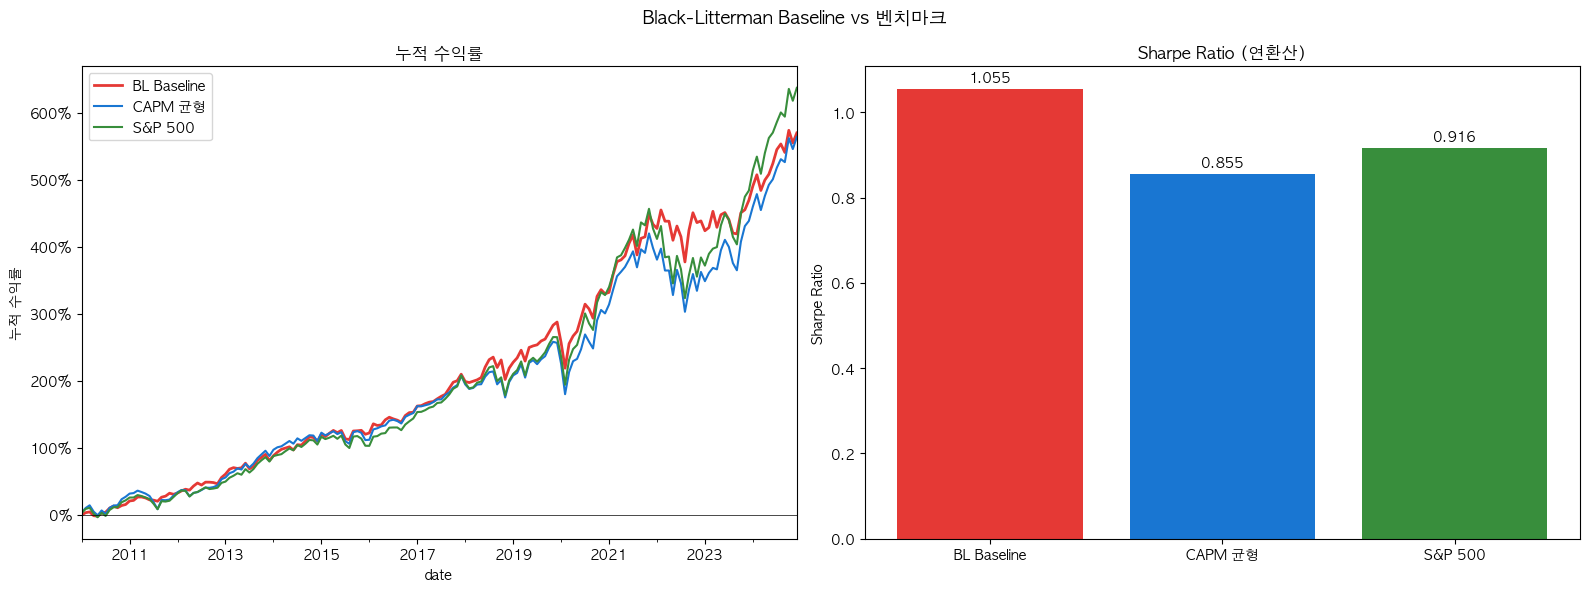

결과 저장 완료


In [40]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Black-Litterman Baseline vs 벤치마크', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for ret, label, color, lw in [
    (bl_ret,   'BL Baseline', '#E53935', 2.0),
    (capm_ret, 'CAPM 균형',   '#1976D2', 1.5),
    (spy_ret,  'S&P 500',     '#388E3C', 1.5),
]:
    cum = (1 + ret).cumprod() - 1
    cum.plot(ax=ax, label=label, color=color, linewidth=lw)
ax.set_title('누적 수익률')
ax.set_ylabel('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio 막대
ax = axes[1]
labels  = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = ['#E53935', '#1976D2', '#388E3C']
bars    = ax.bar(labels, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'bl_baseline_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame({'bl': bl_ret, 'capm': capm_ret, 'spy': spy_ret})
result_df.to_csv(DATA_DIR / 'bl_baseline_returns.csv')
print('결과 저장 완료')

## Q 방식별 성능 비교 (2011–2024)

8가지 Q 추정 방식을 동일 조건에서 walk-forward 비교한다.  
`vol_predicted.csv`(GARCH)가 2011-01부터 제공되므로 비교 기간을 2011-01부터 시작한다.

**2-pass 설계:**
- **Pass 1** — Q_CANDIDATES(8개) 전수 탐색 + 공유 데이터(Σ, π, P, Ω, 신호) 캐시
- **Q_OPTIMAL 결정** — 매월 expanding window Sharpe로 최적 Q 갱신 (초기 24개월은 Q_FIXED 사용, 사후 선택 편향 없음)
- **Pass 2** — 캐시 재사용, 적응형 Q 방식(Q_fixed, Q_lambda, Regime3, Regime+λ, raw_lam_Q, π_ratio, Q_vol_spread, Q_ff3) 실행

| Q 방식 | 신호 소스 | 설명 |
|--------|---------|------|
| Q_FIXED | expanding window Sharpe | 매월 과거 전체로 선택한 최적 Q (편향 없음) |
| Q_lambda | 시장 위험회피계수 λ | λ/λ_mean 비율로 Q 스케일 |
| Regime3 | SPY 변동성 레짐 | 고변동성 → Q=0, 중간 → Q×0.5, 저변동성 → Q |
| Regime+λ | 레짐 + λ | Regime3 하드스탑 + Q_lambda 연속 스케일 |
| raw_lam_Q | raw λ 부호 | SPY 초과수익 음수 시 Q=0 자연 게이팅 |
| π_ratio | CAPM 스프레드 비율 | \|P·π\| / expanding 중앙값으로 Q 스케일 |
| Q_vol_spread+하드스탑 | GARCH vol 격차 + 레짐 | vol_spread 스케일러 + 고변동성 하드스탑 |
| Q_ff3 | FF3 팩터 회귀 | 시장·규모·가치 팩터로 기대수익 추정 → P 가중합 (비교 목적) |

In [41]:
# ── GARCH 예측 vol 로드 ──────────────────────────────────────
_vp = pd.read_csv(DATA_DIR / 'vol_predicted.csv', parse_dates=['date'])
vol_pred_pivot_q = _vp.set_index(['date', 'ticker'])['vol_pred'].unstack('ticker')
print(f'GARCH 예측 로드: {vol_pred_pivot_q.shape}  '
      f'({vol_pred_pivot_q.index[0].date()} ~ {vol_pred_pivot_q.index[-1].date()})')

# ── Q_CANDIDATES: 최적 Q 탐색 후보군 ─────────────────────────
Q_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.007, 0.010, 0.015, 0.020]

# ── 공유 헬퍼 ─────────────────────────────────────────────────
LAM_MEAN    = 2.5
REGIME3_MAP = {'저변동성': 1.0, '중간': 0.5, '고변동성': 0.0}

def get_regime(spy_ser, all_d, idx):
    """SPY 12m 롤링 변동성의 expanding 분위수로 레짐 분류."""
    spy_up  = spy_ser.reindex(all_d[:idx+1]).dropna()
    vol12   = spy_up.rolling(12, min_periods=6).std() * np.sqrt(12)
    clean   = vol12.dropna()
    current = float(vol12.iloc[-1]) if len(vol12) > 0 else np.nan
    if np.isnan(current) or len(clean) < 6:
        return '중간'
    pct = (clean < current).mean()
    return '고변동성' if pct > 0.67 else ('중간' if pct > 0.33 else '저변동성')

# ── FF3 데이터 로드 / compute_Q_ff3 ──────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드 (캐시): {ff3.shape}  ({ff3.index[0].date()} ~ {ff3.index[-1].date()})')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 다운로드+저장 완료: {ff3.shape}')

# 비교 기간: GARCH 데이터 시작(2011-01) & 관측 기간 상한(END_PRED)
START_PRED_Q = '2011-01-01'
pred_dates_q = all_dates[(all_dates >= START_PRED_Q) & (all_dates <= END_PRED)]
print(f'비교 기간: {pred_dates_q[0].date()} ~ {pred_dates_q[-1].date()}  ({len(pred_dates_q)}개월)')
print('헬퍼 함수 정의 완료')

GARCH 예측 로드: (180, 610)  (2011-01-31 ~ 2025-12-31)
FF3 로드 (캐시): (1196, 4)  (1926-07-31 ~ 2026-02-28)
비교 기간: 2011-01-31 ~ 2024-12-31  (168개월)
헬퍼 함수 정의 완료


In [42]:
# ── Walk-forward Pass 1: Q 민감도 탐색 + 공유 데이터 캐시 ────
# Sigma·pi·P·omega를 한 번 계산하여 캐시 → Pass 2에서 재사용
print(f'Pass 1: Q 민감도 탐색  ({len(pred_dates_q)}개월 × {len(Q_CANDIDATES)} 후보)')

_rf_all             = panel['rf_1m'].groupby(level='date').first()
sens_raw            = {f'Q={q}': [] for q in Q_CANDIDATES}
capm_lst            = []
spy_lst             = []
err_lst             = []
_shared_cache       = {}   # {pred_date: dict of shared values}
q_optimal_per_month = {}   # {pred_date: q_opt_t} — expanding window Q (편향 없음)

pi_spread_hist  = []
vol_spread_hist = []

for i, pred_date in enumerate(pred_dates_q):
    if (i + 1) % 24 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates_q)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue

        universe = month_df.index.tolist()
        idx      = all_dates.get_loc(pred_date)
        train_dt = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        thresh   = int(len(train_dt) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dt, columns=universe)
                              .dropna(axis=1, thresh=thresh).fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue

        month_df  = month_df.reindex(valid_tix)
        Sigma_df  = compute_sigma(ret_slice)
        mcap      = np.exp(month_df['log_mcap'])
        w_mkt     = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        spy_s     = spy_series.reindex(train_dt)
        rf_s      = rf_series.reindex(train_dt)
        spy_excess_mean = (spy_s - rf_s).mean()
        spy_var         = spy_s.var()
        lam_raw         = float(spy_excess_mean / spy_var) if spy_var > 0 else 0.0
        pi_v, lam       = compute_pi(Sigma_df, w_mkt, spy_excess_mean, spy_var)

        P     = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P     = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma_df, TAU)

        # Q_ff3 계산 (FF3 회귀 기반)
        q_ff3_val = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dt), rf_s)

        # 공유 신호
        regime    = get_regime(spy_series, all_dates, idx)
        lam_scale = float(np.clip(lam / LAM_MEAN, 0.1, 3.0))
        spread_t  = abs(float(P @ pi_v))
        pi_spread_hist.append(spread_t)
        spread_ref = float(np.median(pi_spread_hist))

        if pred_date in vol_pred_pivot_q.index:
            pv     = vol_pred_pivot_q.loc[pred_date].reindex(valid_tix).fillna(0)
            vs_t   = float(pv[P < 0].mean() - pv[P > 0].mean())
            vol_spread_hist.append(vs_t)
            vs_ref = float(np.median(vol_spread_hist))
            vs_ok  = True
        else:
            vs_t = vs_ref = 0.0
            vs_ok = False

        # 다음달 수익률
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                      if next_date else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))
        r_spy = float(spy_series.get(next_date, np.nan)) if next_date else np.nan

        # Expanding window Q 선택 (이번 달 결과 반영 전 — 과거 데이터만 사용)
        if i >= 24:
            _past_sharpes = {}
            for _key, _lst in sens_raw.items():
                if len(_lst) >= 12:
                    _r   = pd.Series([x['ret'] for x in _lst])
                    _exc = _r - _rf_all.reindex(_r.index).fillna(0)
                    if _exc.std() > 0:
                        _past_sharpes[_key] = float(_exc.mean() / _exc.std() * np.sqrt(12))
            if _past_sharpes:
                _best_t = max(_past_sharpes, key=_past_sharpes.get)
                q_opt_t = float(_best_t.split('=')[1])
            else:
                q_opt_t = Q_FIXED
        else:
            q_opt_t = Q_FIXED   # 초기 24개월: 과거 부족 → fallback
        q_optimal_per_month[pred_date] = q_opt_t

        # Q 후보 BL + MVO
        for q_c in Q_CANDIDATES:
            mu_BL = black_litterman(pi_v, Sigma_df, P, q_c, omega, TAU)
            w     = optimize_portfolio(mu_BL, Sigma_df, lam)
            sens_raw[f'Q={q_c}'].append({'date': pred_date, 'ret': float(w @ actual_ret)})

        # CAPM 벤치마크
        w_capm = optimize_portfolio(pi_v, Sigma_df, lam)
        capm_lst.append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        spy_lst.append( {'date': pred_date, 'ret': r_spy})

        # Pass 2용 캐시 저장
        _shared_cache[pred_date] = dict(
            pi_v=pi_v, lam=lam, lam_raw=lam_raw,
            Sigma_np=Sigma_df.values.copy(),   # numpy 배열로 저장
            Sigma_idx=valid_tix,
            P=P, omega=omega, actual_ret=actual_ret,
            regime=regime, lam_scale=lam_scale,
            spread_t=spread_t, spread_ref=spread_ref,
            vs_t=vs_t, vs_ref=vs_ref, vs_ok=vs_ok,
            q_ff3=q_ff3_val,
            q_optimal=q_opt_t,
        )
    except Exception as e:
        err_lst.append({'date': pred_date, 'error': str(e)})
        if len(err_lst) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')

print(f'\nPass 1 완료: {len(capm_lst)}개월, 에러: {len(err_lst)}건')

# ── Q_OPTIMAL 탐색 (전체 기간 기준 — 표시/참고용, Pass 2 미사용) ──
_sharpes_cand = {}
for key, lst in sens_raw.items():
    if lst:
        r    = pd.DataFrame(lst).set_index('date')['ret']
        rf_a = _rf_all.reindex(r.index).fillna(0)
        exc  = r - rf_a
        _sharpes_cand[key] = float(exc.mean() / exc.std() * np.sqrt(12))

print('\nQ 민감도 탐색 결과 (참고용 — 전 기간 in-sample):')
for k, v in sorted(_sharpes_cand.items(), key=lambda x: -x[1]):
    print(f'  {k}: Sharpe {v:.4f}')

best_key  = max(_sharpes_cand, key=_sharpes_cand.get)
Q_OPTIMAL = float(best_key.split('=')[1])
print(f'\n→ Q_OPTIMAL(참고) = {Q_OPTIMAL}  (Sharpe {_sharpes_cand[best_key]:.4f})')
print(f'  ※ Pass 2 q_fixed는 expanding window Q를 사용하므로 이 값은 참고용입니다.')

Pass 1: Q 민감도 탐색  (168개월 × 8 후보)
  2012-12-31 (24/168)
  2014-12-31 (48/168)
  2018-12-31 (96/168)
  2020-12-31 (120/168)
  2022-12-31 (144/168)
  2024-12-31 (168/168)

Pass 1 완료: 168개월, 에러: 0건

Q 민감도 탐색 결과 (참고용 — 전 기간 in-sample):
  Q=0.007: Sharpe 1.0414
  Q=0.005: Sharpe 1.0409
  Q=0.01: Sharpe 1.0383
  Q=0.003: Sharpe 1.0281
  Q=0.002: Sharpe 1.0044
  Q=0.015: Sharpe 0.9937
  Q=0.001: Sharpe 0.9754
  Q=0.02: Sharpe 0.9505

→ Q_OPTIMAL(참고) = 0.007  (Sharpe 1.0414)
  ※ Pass 2 q_fixed는 expanding window Q를 사용하므로 이 값은 참고용입니다.


In [ ]:
# ── Walk-forward Pass 2: 적응형 Q 방식 (캐시 재사용) ─────────
# Sigma 재계산 없이 BL+MVO만 실행 → 빠름
OTHER_METHODS = ['q_fixed', 'q_lambda', 'regime3', 'regime_lambda', 'raw_lam_q', 'pi_ratio', 'vol_spread', 'q_ff3']
q_other_raw   = {m: [] for m in OTHER_METHODS}

for pred_date, c in _shared_cache.items():
    try:
        Sigma_df = pd.DataFrame(c['Sigma_np'],
                                index=c['Sigma_idx'], columns=c['Sigma_idx'])
        pi_v, lam = c['pi_v'], c['lam']
        P, omega   = c['P'], c['omega']
        actual_ret = c['actual_ret']
        regime, lam_scale              = c['regime'], c['lam_scale']
        lam_raw                        = c['lam_raw']
        spread_t, spread_ref           = c['spread_t'], c['spread_ref']
        vs_t, vs_ref, vs_ok            = c['vs_t'], c['vs_ref'], c['vs_ok']
        q_ff3_val                      = c['q_ff3']
        q_opt_t                        = c['q_optimal']   # expanding window Q

        q_vals = {
            'q_fixed':       q_opt_t,
            'q_lambda':      q_opt_t * lam_scale,
            'regime3':       q_opt_t * REGIME3_MAP[regime],
            'regime_lambda': 0.0 if regime == '고변동성' else q_opt_t * lam_scale,
            'raw_lam_q':     max(0.0, q_opt_t * (lam_raw / LAM_MEAN)),
            'pi_ratio':      q_opt_t * float(np.clip(spread_t / spread_ref, 0.1, 3.0)),
            'vol_spread':    (0.0 if regime == '고변동성'
                              else q_opt_t * float(np.clip(vs_t / vs_ref, 0.1, 3.0))
                              if vs_ok else q_opt_t),
            'q_ff3':         q_ff3_val,
        }
        for method, q in q_vals.items():
            mu_BL = black_litterman(pi_v, Sigma_df, P, q, omega, TAU)
            w     = optimize_portfolio(mu_BL, Sigma_df, lam)
            q_other_raw[method].append({'date': pred_date, 'ret': float(w @ actual_ret)})
    except Exception as e:
        pass

print(f'Pass 2 완료: {len(q_other_raw["q_lambda"])}개월')

# ── Series 변환 ──────────────────────────────────────────────
def to_ser(lst):
    return pd.DataFrame(lst).set_index('date')['ret']

Q_METHODS = ['q_fixed', 'q_lambda', 'regime3', 'regime_lambda', 'raw_lam_q', 'pi_ratio', 'vol_spread', 'q_ff3']
ret_q = {
    'q_fixed':       to_ser(q_other_raw['q_fixed']),
    'q_lambda':      to_ser(q_other_raw['q_lambda']),
    'regime3':       to_ser(q_other_raw['regime3']),
    'regime_lambda': to_ser(q_other_raw['regime_lambda']),
    'raw_lam_q':     to_ser(q_other_raw['raw_lam_q']),
    'pi_ratio':      to_ser(q_other_raw['pi_ratio']),
    'vol_spread':    to_ser(q_other_raw['vol_spread']),
    'q_ff3':         to_ser(q_other_raw['q_ff3']),
}
ret_capm_q = to_ser(capm_lst)
ret_spy_q  = to_ser(spy_lst)

METHOD_META = {
    'q_fixed':       ('Q_FIXED (expanding)',    '#E53935'),
    'q_lambda':      ('Q_lambda',               '#FF9800'),
    'regime3':       ('Regime3',                '#9C27B0'),
    'regime_lambda': ('Regime+λ 하드스탑',       '#673AB7'),
    'raw_lam_q':     ('raw_lam_Q',               '#00BCD4'),
    'pi_ratio':      ('π_ratio',                '#2196F3'),
    'vol_spread':    ('Q_vol_spread\n+하드스탑', '#009688'),
    'q_ff3':         ('Q_ff3',                  '#FF7043'),
}

rf_q = panel['rf_1m'].groupby(level='date').first().reindex(
    ret_q['q_fixed'].index).fillna(0)

def perf_q(ret, rf_aligned, label):
    excess  = ret - rf_aligned.reindex(ret.index).fillna(0)
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * np.sqrt(12)
    sharpe  = excess.mean() / excess.std() * np.sqrt(12)
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    return dict(label=label, ann_ret=ann_ret, ann_vol=ann_vol,
                sharpe=sharpe, mdd=mdd, ret=ret)

print('=' * 70)
print(f'Q 방식별 성능 비교  ({pred_dates_q[0].date()} ~ {pred_dates_q[-1].date()})')
print('=' * 70)
print(f"{'방식':<24} {'연수익':>8} {'변동성':>8} {'Sharpe':>8} {'MDD':>8}")
print('-' * 70)
all_perf_q = []
for method, (label, _) in METHOD_META.items():
    s = perf_q(ret_q[method], rf_q, label.replace('\n', ' '))
    all_perf_q.append(s)
    print(f"{s['label']:<24} {s['ann_ret']:>8.2%} {s['ann_vol']:>8.2%} "
          f"{s['sharpe']:>8.3f} {s['mdd']:>8.2%}")
print('-' * 70)
for ret_b, lbl in [(ret_capm_q, 'CAPM 균형'), (ret_spy_q, 'S&P 500')]:
    s = perf_q(ret_b, rf_q, lbl)
    all_perf_q.append(s)
    print(f"{s['label']:<24} {s['ann_ret']:>8.2%} {s['ann_vol']:>8.2%} "
          f"{s['sharpe']:>8.3f} {s['mdd']:>8.2%}")

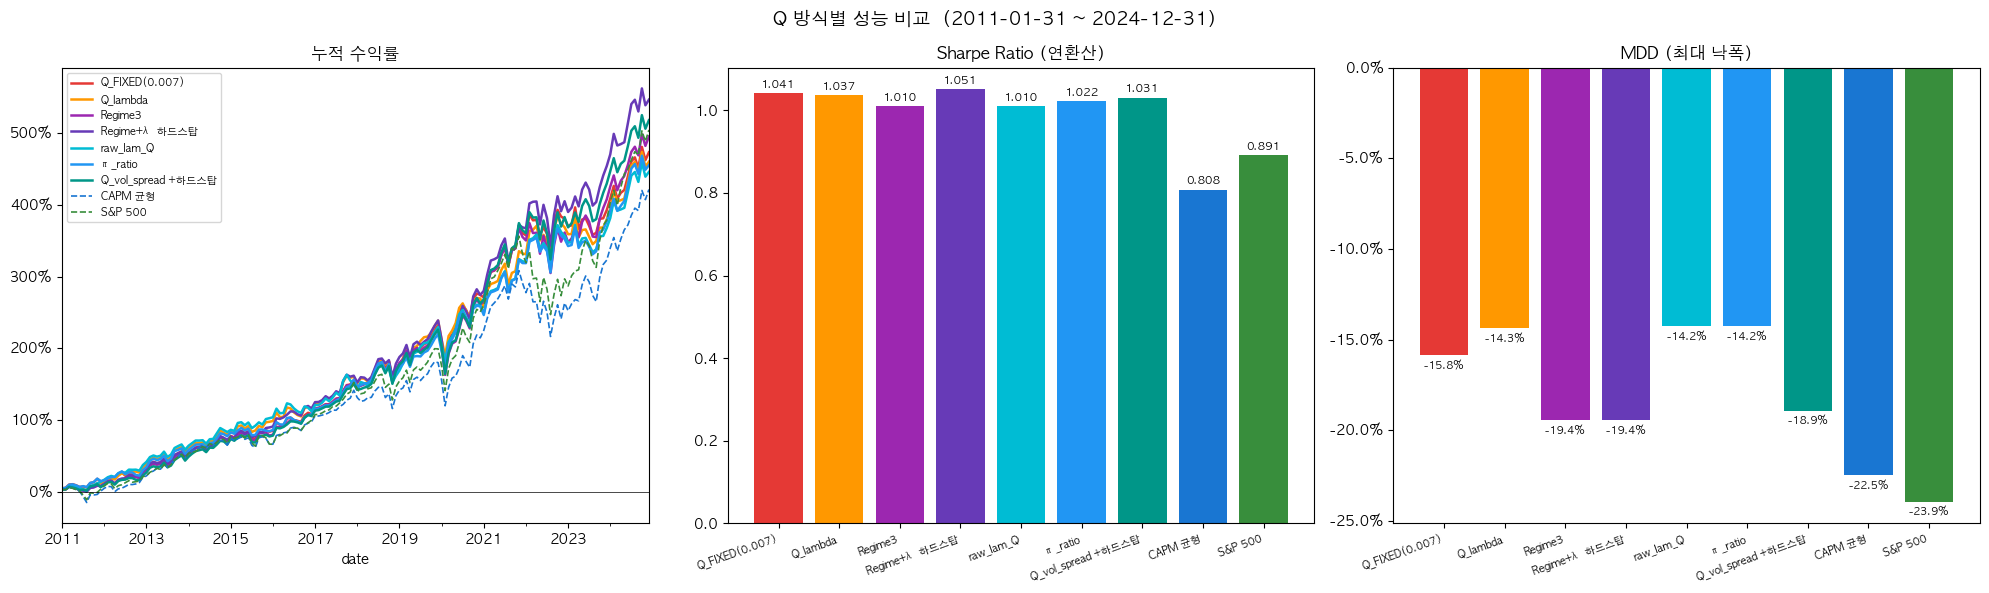

차트 저장: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/low_risk/outputs/99_baseline/q_method_comparison.png
반환 시계열 저장 완료


In [ ]:
# ── 시각화 ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Q 방식별 성능 비교  ({pred_dates_q[0].date()} ~ {pred_dates_q[-1].date()})',
             fontsize=13, fontweight='bold')

_COLORS = {m: METHOD_META[m][1] for m in Q_METHODS}

# ① 누적 수익률
ax = axes[0]
for method in Q_METHODS:
    lbl = METHOD_META[method][0].replace('\n', ' ')
    cum = (1 + ret_q[method]).cumprod() - 1
    cum.plot(ax=ax, label=lbl, color=_COLORS[method], linewidth=1.8)
for ret_b, lbl, col in [(ret_capm_q, 'CAPM 균형', '#1976D2'),
                         (ret_spy_q,  'S&P 500',   '#388E3C')]:
    ((1 + ret_b).cumprod() - 1).plot(ax=ax, label=lbl, color=col,
                                      linestyle='--', linewidth=1.2)
ax.set_title('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=7.5)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio 막대
ax = axes[1]
sharpe_vals = [s['sharpe'] for s in all_perf_q]
sharpe_lbls = [s['label'] for s in all_perf_q]
bar_colors  = [_COLORS.get(m, '#888888') for m in Q_METHODS] + ['#1976D2', '#388E3C']
bars = ax.bar(range(len(sharpe_vals)), sharpe_vals, color=bar_colors)
ax.set_xticks(range(len(sharpe_vals)))
ax.set_xticklabels(sharpe_lbls, fontsize=7.5, rotation=20, ha='right')
ax.set_title('Sharpe Ratio (연환산)')
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, sharpe_vals):
    offset = 0.008 if val >= 0 else -0.04
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ③ MDD 막대
ax = axes[2]
mdd_vals = [s['mdd'] for s in all_perf_q]
bars = ax.bar(range(len(mdd_vals)), mdd_vals, color=bar_colors)
ax.set_xticks(range(len(mdd_vals)))
ax.set_xticklabels(sharpe_lbls, fontsize=7.5, rotation=20, ha='right')
ax.set_title('MDD (최대 낙폭)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, mdd_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val - 0.003,
            f'{val:.1%}', ha='center', va='top', fontsize=7.5)

plt.tight_layout()
out_path = OUT_DIR / 'q_method_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'차트 저장: {out_path}')

# 반환 시계열 저장
ret_df_q = pd.DataFrame(
    {METHOD_META[m][0].replace('\n', '_'): ret_q[m] for m in Q_METHODS})
ret_df_q['CAPM'] = ret_capm_q
ret_df_q['SPY']  = ret_spy_q
ret_df_q.to_csv(DATA_DIR / 'q_method_comparison_returns.csv')
print('반환 시계열 저장 완료')